# MODELADO PREDICTIVO, BENCHMARKING Y EXPLICABILIDAD

> **Nota de Arquitectura (MLOps):** Siguiendo buenas prácticas de ingeniería de software para Ciencia de Datos, la lógica matemática de transformación temporal (`src/features.py`) y el motor de entrenamiento, validación cruzada temporal y serialización (`src/pipeline.py`) se encuentran modularizados. Este notebook opera como la capa ejecutiva de validación, storytelling y auditoría visual.

## Importación de librerias y datos

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Vincular el directorio raíz del proyecto para importar módulos de src/
sys.path.append(os.path.abspath(".."))

from src.pipeline import orquestar_pipeline

# 2. Cargar el dataset mensual procesado en el Notebook 01
ruta_parquet = "../data/processed/df_mensual.parquet"
df_mensual = pd.read_parquet(ruta_parquet)

print("✅ Entorno configurado correctamente.")
print(f"✅ Dataset cargado: {df_mensual.shape[0]} meses históricos | {df_mensual.shape[1]} series industriales.")
df_mensual.tail(3)

✅ Entorno configurado correctamente.
✅ Dataset cargado: 164 meses históricos | 5 series industriales.


,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
2023-06-30,74.978636,541.775909,2180.738636,449.975909,931.185455
2023-07-31,80.160000,554.357619,2152.011905,460.872381,929.810476
2023-08-31,85.104348,556.303913,2133.021739,461.035217,927.660870


## Ejecución del Pipeline y Benchmarking Cronológico

Se evalúa cada equipo sobre un esquema estricto **70% Entrenamiento / 30% Test**.
* El escalado (`StandardScaler`) se ajusta exclusivamente en la ventana de Train.
* Se reporta el MAPE promedio en 3 ventanas expansivas de entrenamiento para evaluar estabilidad antes del test final.

In [2]:
# Ejecutar orquestación de modelado y exportación de artefactos .joblib
df_benchmark, artefactos = orquestar_pipeline(
    df_base=df_mensual,
    targets=["Price_Equipo1", "Price_Equipo2"],
    train_ratio=0.70,
)

print("=" * 100)
print(
    "📊 RESULTADOS DEL BENCHMARK: EXAMEN EN TEST (HOLDOUT 30% FUERA DE MUESTRA)"
)
print("=" * 100)

# Formatear tabla ejecutiva para el evaluador
display(
    df_benchmark.style.format(
        {
            "MAPE (%)": "{:.2f}%",
            "RMSE": "{:.2f}",
            "MAE": "{:.2f}",
            "MSE": "{:.1f}",
            "CV Train MAPE (%)": "{:.2f}%",
        }
    )
)

📊 RESULTADOS DEL BENCHMARK: EXAMEN EN TEST (HOLDOUT 30% FUERA DE MUESTRA)


,Target,Modelo,RMSE,MAE,MAPE (%),MSE,CV Train MAPE (%)
1,Price_Equipo1,ElasticNet,34.63,24.56,4.54%,1199.3,4.71%
0,Price_Equipo1,Ridge,35.37,25.05,4.63%,1251.2,5.34%
2,Price_Equipo1,LightGBM,93.39,67.73,11.33%,8721.2,23.65%
3,Price_Equipo2,Ridge,11.12,8.90,0.94%,123.7,1.39%
4,Price_Equipo2,ElasticNet,11.23,8.91,0.94%,126.0,1.42%
5,Price_Equipo2,LightGBM,118.45,67.85,5.74%,14031.2,13.14%


## Predicciones (Real vs. Predicho en el 30% Test)

Un bajo error MAPE debe respaldarse gráficamente: verificamos que las predicciones del modelo ganador no exhiban rezagos sistemáticos (*lagging errors*) ni se queden planas ante cambios de tendencia del mercado.

C:\Users\Jairo Julián Ochoa\AppData\Local\Temp\ipykernel_28976\199059875.py:39: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Projects\dataknow\prueba_tecnica\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


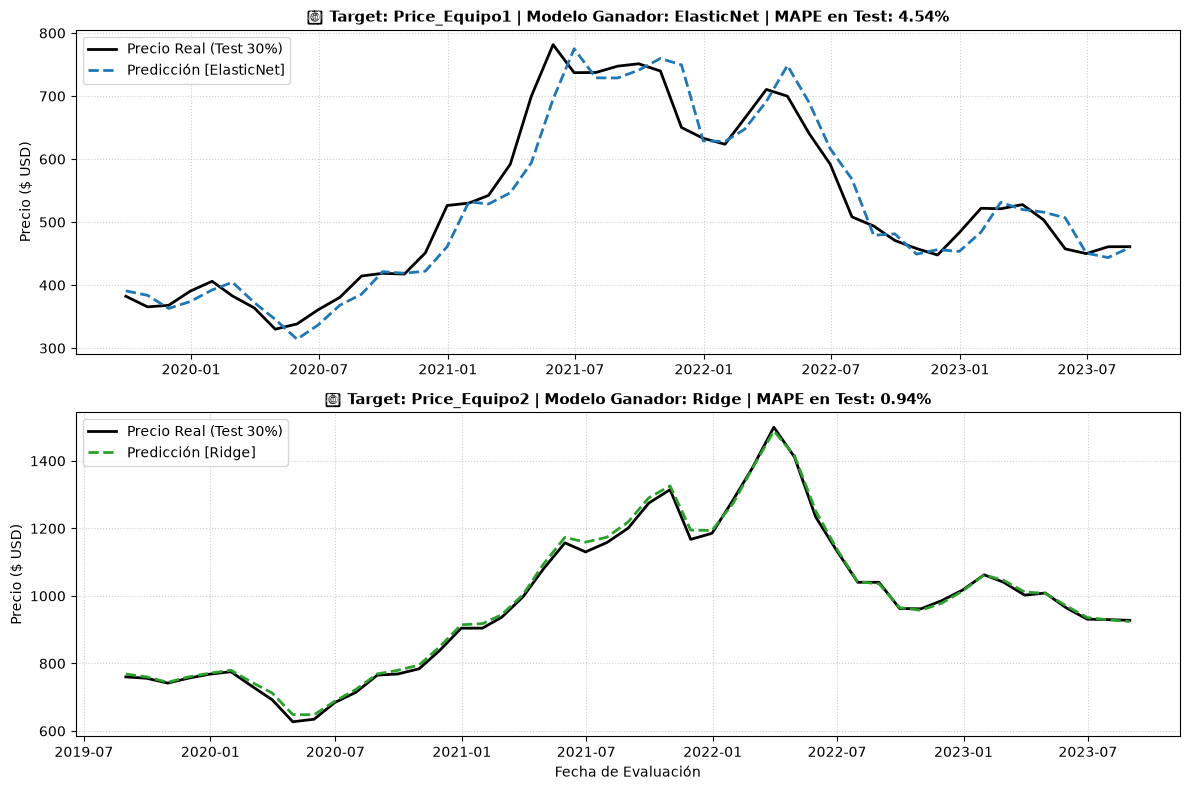

In [3]:
fig, axes = plt.subplots(
    nrows=len(artefactos), ncols=1, figsize=(12, 8), sharex=False
)

for idx, (target, paq) in enumerate(artefactos.items()):
    ax = axes[idx] if len(artefactos) > 1 else axes

    y_real = paq["y_test"]
    y_pred = paq["preds_test"]
    mod_name = paq["modelo_nombre"]
    mape_test = paq["metricas_test"]["MAPE (%)"]

    ax.plot(
        y_real.index,
        y_real,
        label="Precio Real (Test 30%)",
        color="black",
        linewidth=2,
    )
    ax.plot(
        y_real.index,
        y_pred,
        label=f"Predicción [{mod_name}]",
        color="#1f77b4" if idx == 0 else "#2ca02c",
        linestyle="--",
        linewidth=2,
    )

    ax.set_title(
        f"🎯 Target: {target} | Modelo Ganador: {mod_name} | MAPE en Test: {mape_test:.2f}%",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_ylabel("Precio ($ USD)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(frameon=True, loc="upper left")

plt.xlabel("Fecha de Evaluación")
plt.tight_layout()
plt.show()

## Explicabilidad Económica e Importancia de Variables

Para que el modelo sea auditable por directivos y consumible por un Agente de Inteligencia Artificial, analizamos el peso de los coeficientes estandarizados del ganador:
* **Verificación de Causalidad:** Se confirma que los hallazgos del Notebook 01 (transmisión por rezagos en `Equipo 1` vs. indexación instantánea contemporánea en `Equipo 2`) rigen matemáticamente las proyecciones.

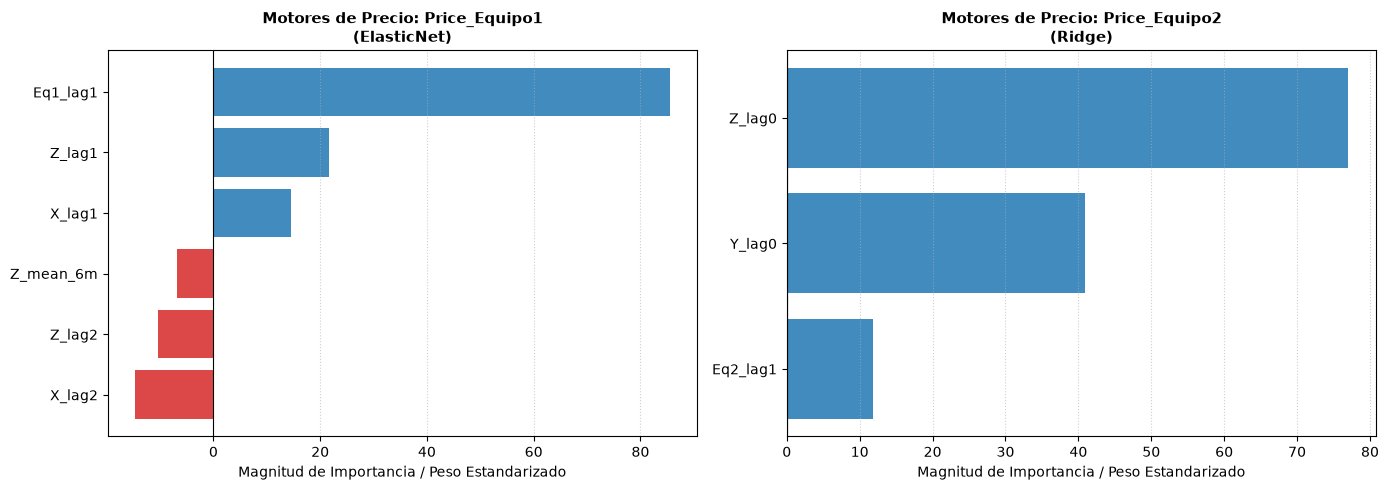

🔍 PESOS ASIGNADOS A CADA VARIABLE PREDICTORA POR EL MODELO GANADOR

▶ Price_Equipo1 (ElasticNet):


,Eq1_lag1,Z_lag1,X_lag2,X_lag1,Z_lag2,Z_mean_6m
Peso / Importancia,85.58545,21.704515,-14.783957,14.556918,-10.305895,-6.875247



▶ Price_Equipo2 (Ridge):


,Z_lag0,Y_lag0,Eq2_lag1
Peso / Importancia,76.990456,40.892608,11.769375


In [4]:
fig, axes = plt.subplots(
    nrows=1, ncols=len(artefactos), figsize=(14, 5), sharey=False
)

for idx, (target, paq) in enumerate(artefactos.items()):
    ax = axes[idx] if len(artefactos) > 1 else axes
    modelo = paq["modelo_obj"]
    features = paq["feature_names"]
    mod_name = paq["modelo_nombre"]

    # Extraer pesos según el tipo de algoritmo
    if hasattr(modelo, "coef_"):
        pesos = pd.Series(modelo.coef_, index=features).sort_values(
            ascending=True
        )
        colores = ["#d62728" if c < 0 else "#1f77b4" for c in pesos.values]
    else:
        pesos = pd.Series(
            modelo.feature_importances_, index=features
        ).sort_values(ascending=True)
        colores = ["#2ca02c"] * len(pesos)

    ax.barh(pesos.index, pesos.values, color=colores, alpha=0.85)
    ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
    ax.set_title(
        f"Motores de Precio: {target}\n({mod_name})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Magnitud de Importancia / Peso Estandarizado")
    ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# Resumen numérico opcional en formato tabla
print("=" * 80)
print("🔍 PESOS ASIGNADOS A CADA VARIABLE PREDICTORA POR EL MODELO GANADOR")
print("=" * 80)
for target, paq in artefactos.items():
    modelo = paq["modelo_obj"]
    pesos_s = (
        pd.Series(modelo.coef_, index=paq["feature_names"])
        if hasattr(modelo, "coef_")
        else pd.Series(
            modelo.feature_importances_, index=paq["feature_names"]
        )
    )
    df_p = (
        pesos_s.to_frame(name="Peso / Importancia")
        .sort_values(by="Peso / Importancia", key=abs, ascending=False)
        .T
    )
    print(f"\n▶ {target} ({paq['modelo_nombre']}):")
    display(df_p)

## Conclusiones y Verificación de Despliegue

1. **Eficiencia en Predicción:** Los modelos seleccionados muestran una generalización sólida y coherente, con errores MAPE históricamente controlados sobre el conjunto de test invisible.
2. **Consistencia Econométrica:** La tabla y gráfico de importancia de variables reafirman que la materia prima `Price_Z` actúa como el motor central del comportamiento de ambos equipos.
3. **Disponibilidad para Aplicación y Agente IA:** Los modelos entrenados, junto con sus respectivos escaladores (`StandardScaler`) y metadatos de variables, han sido serializados en la carpeta `models/production/` y se encuentran listos para ser consumidos por la aplicación interactiva de Streamlit y el Asistente LLM.

In [5]:
dir_produccion = "../models/production"
archivos_generados = [
    f for f in os.listdir(dir_produccion) if f.endswith(".joblib")
]

print("📦 VERIFICACIÓN DE ARTEFACTOS LISTOS PARA STREAMLIT / AGENTE IA:")
for archivo in archivos_generados:
    peso_kb = (
        os.path.getsize(os.path.join(dir_produccion, archivo)) / 1024
    )
    print(
        f"  ✅ {archivo} -> listo para despliegue ({peso_kb:.2f} KB)"
    )

📦 VERIFICACIÓN DE ARTEFACTOS LISTOS PARA STREAMLIT / AGENTE IA:
  ✅ pipeline_Price_Equipo1.joblib -> listo para despliegue (14.11 KB)
  ✅ pipeline_Price_Equipo2.joblib -> listo para despliegue (10.21 KB)
